# MLP Model
This is the 4th model we are using to analyze our data. The goal is to compare each model's complexity and accuracy.

### Our approach:
*   Import the data with standardized file/path names to match our main document
*   Use the FFNN setup from HW3 as the baseline for this neural network
*   Implement random search using keras tuner, identifying the best hyperparameters
*   Create a second model using "top-k" accuracy
*   Plotting & comparing the models, to validate that the model is training as expected and that the results are fairly accurate
*   Quantify the model complexity and accuracy

### Improvements/optimizations attempted
*   Adding dropout layers to prevent model overfitting, especially at higher node counts
*   Testing out "top-k" accuracy, meaning the model is considered correct if one out of the top-k guesses correctly matches the music genre
*   Using random search to optimize the number of nodes in each layer, the learning rate, and the k in "top-k" analysis.



Starting with the data import:

In [1]:
# May need to change the path for the CSV when we combine into the big .ipynb file

import pandas as pd

X_train = pd.read_csv('/content/X_train_scaled.csv')
X_test = pd.read_csv('/content/X_test_scaled.csv')
Y_train = pd.read_csv('/content/Y_train.csv')
Y_test = pd.read_csv('/content/Y_test.csv')

# found the genre mapping from the preprocessing .ipynb file
genre_mapping = {
    0: 'edm',
    1: 'hiphop',
    2: 'latin',
    3: 'pop',
    4: 'r&b',
    5: 'rap',
    6: 'rock'
}

Y_train['Genre_Name'] = Y_train['Genre'].map(genre_mapping)
Y_test['Genre_Name'] = Y_test['Genre'].map(genre_mapping)

print("Unique Genres:", Y_train['Genre_Name'].unique())

Unique Genres: ['r&b' 'rock' 'latin' 'rap' 'pop' 'hiphop' 'edm']


The following is based heavily on HW3, and used as a basis/comparison for the optimized NN for this problem.

In [2]:
" Unoptimized code, used as a reference to see how much "

"we will utilize a FFNN to capture hidden interactions between features."
"fully connected nodes and non-linear activation functions"
"11 X-vars (features/attributes/predictors/dimensions), 1 Y-prediction (genre)"
"there are 7 genres"

from tensorflow.keras.layers import Dropout
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD # stochastic gradient descent

def prior_model(hp):
  input_dim = 11
  # in order to allow keras_tuner to run, I have to leave the parameters defined as a testable range
  # coding the variable hp based on: https://medium.com/swlh/hyperparameter-tuning-in-keras-tensorflow-2-with-keras-tuner-randomsearch-hyperband-3e212647778f
  hidden_dim_1 = hp.Int('units_1', min_value=10, max_value=100, step=10)
  hidden_dim_2 = hp.Int('units_2', min_value=10, max_value=100, step=10)
  hidden_dim_3 = hp.Int('units_3', min_value=10, max_value=100, step=10)
  output_dim = 7
  learn_rate = hp.Float('learning_rate', min_value=0.001, max_value=0.5)

  old_model = Sequential()

  # when i use ReLU instead of sigmoid, i get actual classification
  # using sigmoid only makes this model fail, especially in confusion matrix later
  old_model.add(Dense(hidden_dim_1, input_dim=input_dim, activation='relu'))
  old_model.add(Dense(hidden_dim_2, activation='relu'))
  # droppout added based on following guide: https://machinelearningmastery.com/dropout-regularization-deep-learning-models-keras/
  old_model.add(Dropout(0.2))
  old_model.add(Dense(hidden_dim_3, activation='relu'))
  old_model.add(Dropout(0.2))
  old_model.add(Dense(output_dim, activation='softmax')) # as per Jake's Piazza instruction

  old_model.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.4))
  return old_model


Now, determining best hyperparameters for the base model:

In [3]:
# pip install keras-tuner --upgrade

In [4]:
# use keras Random Search tuner
# based on https://keras.io/keras_tuner/

import keras_tuner

def find_hp(which_model, name):
  tuner = keras_tuner.RandomSearch(
      which_model,
      objective='val_loss',
      max_trials=10,
      overwrite=True)
  # for the best-k searching as well
  tuner.search(X_train, Y_train['Genre'], epochs=10, validation_data=(X_test, Y_test['Genre']))
  best_model = tuner.get_best_models()[0]

  # getting the hyperparameters:
  best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

  best_dim_1 = best_hps.get('units_1')
  best_dim_2 = best_hps.get('units_2')
  best_dim_3 = best_hps.get('units_3')
  best_learn_rate = best_hps.get('learning_rate')

  print(f'{name} ***************')
  print(f'hidden_dim_1 = {best_dim_1}')
  print(f'hidden_dim_2 = {best_dim_2}')
  print(f'hidden_dim_3 = {best_dim_3}')
  print(f'learning_rate = {best_learn_rate}')
  if name == 'OPTIMIZATION WITH TOP-K ERROR':
    print(f'chosen K = {best_hps.get("TopK")}')
  print('*********************')

  return best_dim_1, best_dim_2, best_dim_3, best_learn_rate, best_model

best_dim_1, best_dim_2, best_dim_3, best_learn_rate, best_prior_model = find_hp(prior_model, 'NORMAL MODEL OPTIMIZATION')

Trial 10 Complete [00h 00m 08s]
val_loss: 1.3288788795471191

Best val_loss So Far: 1.2488600015640259
Total elapsed time: 00h 01m 30s
NORMAL MODEL OPTIMIZATION ***************
hidden_dim_1 = 100
hidden_dim_2 = 40
hidden_dim_3 = 70
learning_rate = 0.05361981803160722
*********************


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The following is similar to the HW3 blurb above, now implementing the "best-k" accuracy analysis. This also includes a bit of hyperparameter tuning to determine exaclty which best-k is ideal.

In [5]:
" New model using top-K genre accuracy "


input_dim = 11
hidden_dim_1 = best_dim_1
hidden_dim_2 = best_dim_2
hidden_dim_3 = best_dim_3
output_dim = 7
learn_rate = best_learn_rate
k_defined = 3

model = Sequential()

# when i use ReLU instead of sigmoid, i get actual classification
# using sigmoid only makes this model fail, especially in confusion matrix later
model.add(Dense(hidden_dim_1, input_dim=input_dim, activation='relu'))
model.add(Dense(hidden_dim_2, activation='relu'))
# droppout added based on following guide: https://machinelearningmastery.com/dropout-regularization-deep-learning-models-keras/
model.add(Dropout(0.2))
model.add(Dense(hidden_dim_3, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(output_dim, activation='softmax')) # as per Jake's Piazza instruction

# implementing top-3 genre matching based on:
# https://medium.com/@juanfraleonhardt/music-genre-classification-a-machine-learning-exercise-9c83108fd2bb
sparse_topK_categorical_accuracy = keras.metrics.SparseTopKCategoricalAccuracy(k = k_defined)

model.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=learn_rate), metrics=[sparse_topK_categorical_accuracy])


In [6]:
# its own cell because it takes so long to run
epoch_number = 50


old_fitted_model = best_prior_model.fit(X_train, Y_train['Genre'], epochs=epoch_number, validation_data=(X_test, Y_test['Genre'])) #batch_size=128,

Epoch 1/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2207 - val_loss: 1.2892
Epoch 2/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2135 - val_loss: 1.4185
Epoch 3/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2088 - val_loss: 1.3317
Epoch 4/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1959 - val_loss: 1.3186
Epoch 5/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1893 - val_loss: 1.2765
Epoch 6/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1931 - val_loss: 1.2703
Epoch 7/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1824 - val_loss: 1.2675
Epoch 8/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1657 - val_loss: 1.3343
Epoch 9/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1682 - val_loss: 1.3079
Epoch 10/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1756 - val_loss: 1.2990
Epoch 11/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1681 - val_loss: 1.2857
Epoch 12/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [7]:
# its own cell because it takes so long to run
best_fitted_model = model.fit(X_train, Y_train['Genre'], epochs=epoch_number, validation_data=(X_test, Y_test['Genre'])) #batch_size=128,

Epoch 1/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7082 - sparse_top_k_categorical_accuracy: 0.6879 - val_loss: 1.4509 - val_sparse_top_k_categorical_accuracy: 0.8035
Epoch 2/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4217 - sparse_top_k_categorical_accuracy: 0.8084 - val_loss: 1.3395 - val_sparse_top_k_categorical_accuracy: 0.8295
Epoch 3/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3478 - sparse_top_k_categorical_accuracy: 0.8269 - val_loss: 1.3091 - val_sparse_top_k_categorical_accuracy: 0.8338
Epoch 4/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3102 - sparse_top_k_categorical_accuracy: 0.8408 - val_loss: 1.3039 - val_sparse_top_k_categorical_accuracy: 0.8439
Epoch 5/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2843 - sparse_top_k_categorical_accuracy: 0.8509 - val_loss: 1.2772 - val_sparse_top_k_categorical_accuracy: 0.8461
Epoch 6/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2606 - sparse_top_k_categorical_accuracy: 0.8538

Plotting and comparing the models

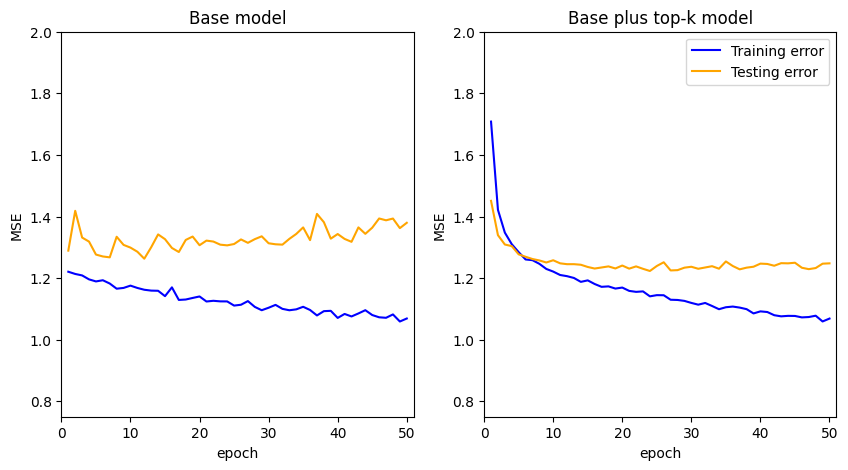

In [8]:
# graph showing reduced mse vs epoch

import matplotlib.pyplot as plt
import numpy as np
fig,(ax1,ax2) = plt.subplots(1,2, figsize=(10,5))#, sharex=True, sharey=True)

epoch = np.arange(1, epoch_number+1)

old_train_mse = old_fitted_model.history['loss']
old_val_mse = old_fitted_model.history['val_loss']
ax1.plot(epoch, old_train_mse, color='blue', linestyle='-', label='Training MSE')
ax1.plot(epoch, old_val_mse, color='orange', linestyle='-', label='Testing MSE')
ax1.set_xlabel('epoch')
ax1.set_ylabel('MSE')
ax1.set_ylim(0.75, 2)
ax1.set_xlim(0, epoch_number+1)
ax1.set_title('Base model')

best_train_sparse_top_k = best_fitted_model.history['loss']
best_val_mse = best_fitted_model.history['val_loss']
best_val_sparse_top_k = best_fitted_model.history['val_sparse_top_k_categorical_accuracy']

ax2.plot(epoch, best_train_sparse_top_k, color='blue', linestyle='-', label='Training error')
ax2.plot(epoch, best_val_mse, color='orange', linestyle='-', label='Testing error')
# ax2.plot(epoch, best_val_sparse_top_k, color='green', linestyle='-', label='Testing SCC error')
ax2.set_xlabel('epoch')
ax2.set_ylabel('MSE')
ax2.set_ylim(0.75, 2)
ax2.set_xlim(0, epoch_number+1)
ax2.set_title('Base plus top-k model')


# plt.xlabel('Epoch')
# plt.ylabel('MSE')
plt.legend()
plt.show()


##Analysis of test/training error per epoch graphs:
*  Test



Confusion matrix and accuracy measurements code:

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.4985549132947977
Precision: 0.5011913700361109
Recall: 0.4865123725429911
F1: 0.48671172053496237


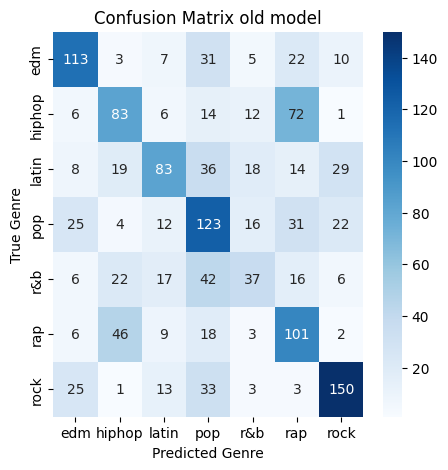

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.5289017341040463
Precision: 0.5315214084898675
Recall: 0.5173932032008174
F1: 0.5208462389044939


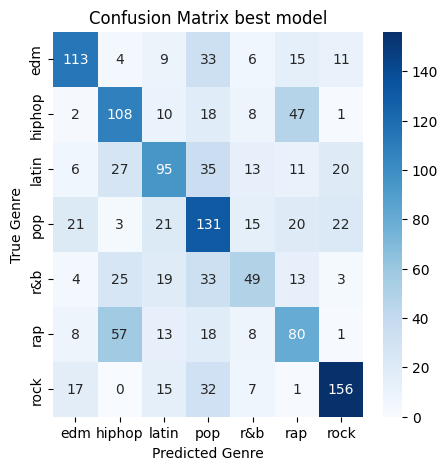

In [9]:
# confusion matrix code borrowed from the kNN section

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

genre_labels = ['edm', 'hiphop', 'latin', 'pop', 'r&b', 'rap', 'rock']

def print_cm(model_name, name):

  Y_pred = model_name.predict(X_test)
  predictions = np.argmax(Y_pred, axis=1)

  accuracy = accuracy_score(Y_test['Genre'], predictions)
  precision = precision_score(Y_test['Genre'], predictions, average='macro')
  recall = recall_score(Y_test['Genre'], predictions, average='macro')
  f1 = f1_score(Y_test['Genre'], predictions, average='macro')

  print("Accuracy:", accuracy)
  print("Precision:", precision)
  print("Recall:", recall)
  print("F1:", f1)

  old_cm = confusion_matrix(Y_test['Genre'], predictions)

  plt.figure(figsize=(5, 5))

  sns.heatmap(
      old_cm,
      annot=True,
      fmt='d',
      cmap='Blues',
      xticklabels=genre_labels,
      yticklabels=genre_labels
  )

  plt.title(f"Confusion Matrix {name}")
  plt.xlabel("Predicted Genre")
  plt.ylabel("True Genre")

  plt.show()

print_cm(best_prior_model, 'old model')
print_cm(model, 'best model')